In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("project1.ipynb")

<table style="width: 100%;">
<tr style="background-color: transparent;">
<td width="100px"><img src="https://cs104williams.github.io/assets/cs104-logo.png" width="90px" style="text-align: center"/></td>
<td>
  <p style="margin-bottom: 0px; text-align: left; font-size: 18pt;"><strong>CSCI 104: Data Science and Computing for All</strong><br>
                Williams College<br>
                Fall 2024</p>
</td>
</tr>


<hr style="margin-bottom: 0px; padding:0; border: 2px solid #500082;"/>

# Midterm Project: World Progress

In this project, you'll explore data from [Gapminder.org](http://gapminder.org), a website dedicated to providing a fact-based view of the world and how it has changed. That site includes several data visualizations and presentations, and it also publishes the raw data that we will use in this project to recreate and extend some of their most famous visualizations.

The Gapminder website collects data from many sources and compiles them into tables that describe many countries around the world. All of the data they aggregate are published in the [Systema Globalis](https://github.com/open-numbers/ddf--gapminder--systema_globalis/blob/master/README.md). Their goal is "to compile all public statistics; Social, Economic and Environmental; into a comparable total dataset." All data sets in this project are copied directly from the Systema Globalis without any changes.


## Honor Code

This project aims to synthesize the material we have covered in this course so far and assess the python and data wrangling skills you have all learned.  As such, **this project is to be completed on your own**. Specifically, the Honor Code as interpreted for this assignment is as follows:

* **You may consult the text, your notes, your lab work, our lecture examples, and the web pages associated with the course web page.  No other resources are permitted.**  You may not search the web, use ChatGPT or similar systems, or any materials other than your own or those provided by the instructors through the course web pages.

* **You may discuss these questions and review general concepts from the class materials with the course instructors and TAs.**  While we expect you to develop your solutions independently, we're happy to answer clarification questions, help you interpret Python error messages, offer general debugging advice, review lecture and lab materials, etc.

* **You may not discuss this project or your solutions with anyone else until after the final submission deadline.**

*Do not hesitate to ask if you are in doubt as to what is appropriate. We're happy to discuss this anytime.*


## Deadlines

* **10pm on Friday, Oct 11: Checkpoint.**  You must complete the first 8 questions, and pass the public autograder tests for those parts.  Submitting this checkpoint is worth 5% of your entire project grade.  After you've submitted the checkpoint, you may still change your answers before the project deadline - only your final submission, to the Project 1 assignment, will be graded for correctness. 

* **10pm on Thursday, Oct 17: Final Due Date.**  The full project must be submitted to Gradescope.

Late days may not be used on the project.

## Instructions

- Before you begin, execute the cell at the TOP of the notebook to load the provided tests, as well as the following cell to setup the notebook by importing some helpful libraries. Each time you start your server, you will need to execute these cells again.  

- Be sure to consult your [Python Reference](https://cs104williams.github.io/assets/python-library-ref.html)!

- Complete this notebook by filling in the cells provided. For problems asking you to write explanations, you **must** provide your answer in the designated space. 

- Please be sure to not re-assign variables throughout the notebook.  For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously.

- This project has hidden tests for some parts. That means even though tests may say 100% passed, doesn't mean your final grade will be 100%. We will be running more tests for correctness once everyone turns in the lab.

## Hints for Success

- You may find some parts of this project challenging.  Keep in mind that a perfect score is not necessary to be highly successful in this class.  Do your best, but please do not worry if you are unable to complete all parts.

- Along those lines, give yourself ample time to think about the material and develop your solutions.  Don't wait until the last minute!

- Develop your answers incrementally. To perform a complicated table manipulation, break it up into steps, perform each step on a different line, give a new name to each result, and check that each intermediate result is what you expect. 

- You may add any additional names or functions you want to the provided cells. Be sure to use distinct and meaningful variable names throughout the notebook, but do not reassign to names we have already used in the notebook. Recall, in the file menu you can select `Kernel > Restart Kernel and Run All Cells` to ensure variables you have deleted are not still in the computer's memory and to run everything from scratch.


<hr/>

In [2]:
# Run this cell to set up the notebook.
# These lines import the numpy, datascience, and cs104 libraries.

import numpy as np
from datascience import *
from cs104 import *
%matplotlib inline

The global population of humans reached 1 billion around 1800, 3 billion around 1960, and 7 billion around 2011. The potential impact of exponential population growth has concerned scientists, economists, and politicians alike.

The UN Population Division estimates that the world population will likely continue to grow throughout the 21st century, but at a slower rate, perhaps reaching 11 billion by 2100. However, the UN does not rule out scenarios of more extreme growth.

<a href="http://www.pewresearch.org/fact-tank/2015/06/08/scientists-more-worried-than-public-about-worlds-growing-population/ft_15-06-04_popcount/"> 
 <img src="pew_population_projection.png"/> 
</a>

We  begin the project by examining some of the factors that influence population growth and how they have been changing over the years and around the world. There are two main sub-parts of this analysis.

- First, we  examine the data for one country, Bangladesh. We will see how factors such as life expectancy, fertility rate, and child mortality have changed over time in Bangladesh, and how they are related to the rate of population growth.
- Next, we  examine whether the changes we have observed for Bangladesh are particular to that country or whether they reflect general patterns observable in other countries too. We will study aspects of world population growth and see how they have been changing.

The first table we  consider contains the total population of each country over time. Run the cell below.    (The population csv file can also be found [here](https://github.com/open-numbers/ddf--gapminder--systema_globalis/blob/master/countries-etc-datapoints/ddf--datapoints--population_total--by--geo--time.csv).)

In [3]:
population = Table.read_table('population.csv').where('Time', are.below(2021))
population.show(3)

Geo,Time,Population
afg,1800,3280000
afg,1801,3280000
afg,1802,3280000


In this table, the `geo` column contains three-letter codes established by the [International Organization for Standardization](https://en.wikipedia.org/wiki/International_Organization_for_Standardization) (ISO) in the [Alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3#Current_codes) standard.

<hr style="margin-bottom: 0px; padding:0; border: 2px solid #500082;"/>


## 1. Population Growth: Bangladesh (40 pts)



The nation of [Bangladesh](https://en.wikipedia.org/wiki/Bangladesh#People's_Republic_of_Bangladesh) was established as a parliamentary democracy after the Bangladesh Liberation War ended in 1971. The war-ravaged fledgling nation was almost immediately faced with floods and famine. In this section of the project, we will examine aspects of the development of Bangladesh since that time. 

Before proceeding, consult the [Alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3#Current_codes) link above to find the 3-letter code for Bangladesh.

#### Part 1.1 (5 pts)


Create a table called `b_pop` that has two columns labeled `Time` and `Population` (in that exact order). The first column should contain the years from 1970 through 2020 (including both 1970 and 2020) and the second should contain the population of Bangladesh in each of those years.



In [4]:
...
b_pop = population.where("Geo", are.equal_to("bgd")).where("Time", are.between_or_equal_to(1970,2020)).drop("Geo")
b_pop

Time,Population
1970,64232486
1971,65531635
1972,66625706
1973,67637541
1974,68742222
1975,70066310
1976,71652386
1977,73463593
1978,75450033
1979,77529040


In [5]:
grader.check("p1.1")

✅ p1.1.1: check(b_pop.labels == ('Time', 'Population'))
✅ p1.1.2: check(b_pop.sort('Time').column('Time') == np.arange(1970, 2021))

Run the following cell to create a table called `b_five` that has the population of Bangladesh every five years. At a glance, it appears that the population of Bangladesh has been growing quickly indeed!

*Note:* You do not need to change or add anything to the cell below. 

In [6]:
b_pop.set_format('Population', NumberFormatter)  # Prints populations with commas

fives = np.arange(1970, 2021, 5) # 1970, 1975, 1980, ...
b_five = b_pop.sort('Time').where('Time', are.contained_in(fives))
b_five.show()

Time,Population
1970,"64,232,486"
1975,"70,066,310"
1980,"79,639,498"
1985,"90,764,180"
1990,"103,171,957"
1995,"115,169,933"
2000,"127,657,862"
2005,"139,035,505"
2010,"147,575,433"
2015,"156,256,287"


#### Part 1.2 (5 pts)


Let's write code to find the population growth rate. 

Assign `initial` to an array that contains the population for every five year interval from 1970 to 2015 (inclusive). Then, assign `changed` to an array that contains the population for every five year interval from 1975 to 2020 (inclusive). The first array should include both 1970 and 2015, and the second array should include both 1975 and 2020. 

You should use the `b_five` table to create both arrays, by first filtering the table to only contain the relevant years.

We have provided the code below that uses  `initial` and `changed` in order to add a column to `b_five` called `annual_growth`. Don't worry about the calculation of the growth rates; run the test below to test your solution.

If you are interested in how we came up with the formula for growth rates, consult the [growth rates](https://inferentialthinking.com/chapters/03/2/1/Growth.html) section of the textbook.



In [7]:
initial = b_five.where("Time", are.between_or_equal_to(1970,2015)).column("Population")
changed = b_five.where("Time", are.between_or_equal_to(1975,2020)).column("Population")

b_1970_through_2015 = b_five.where('Time', are.below_or_equal_to(2015)) 
b_five_growth = b_1970_through_2015.with_column('Annual Growth', (changed/initial)**(1/5)-1)
b_five_growth.set_format('Annual Growth', PercentFormatter)

Time,Population,Annual Growth
1970,"64,232,486",1.75%
1975,"70,066,310",2.59%
1980,"79,639,498",2.65%
1985,"90,764,180",2.60%
1990,"103,171,957",2.22%
1995,"115,169,933",2.08%
2000,"127,657,862",1.72%
2005,"139,035,505",1.20%
2010,"147,575,433",1.15%
2015,"156,256,287",1.06%


In [8]:
grader.check("p1.2")

✅ p1.2.1: check(0.005 <= b_five_growth.sort('Time').column('Annual Growth').item(0) <= 0.05)
✅ p1.2.2: check(0.01 < max(b_five_growth.column('Annual Growth')) < 0.03)

While the population has grown every five years since 1970, the annual growth rate decreased dramatically from 1985 to 2015. Let's look at some other information in order to develop a possible explanation. Run the next cell to load three additional tables of measurements about countries over time.

In [9]:
life_expectancy = Table.read_table('life_expectancy.csv').where('Time', are.below(2021))
child_mortality = Table.read_table('child_mortality.csv').where('Time', are.below(2021))
fertility = Table.read_table('fertility.csv').where('Time', are.below(2021))

The `life_expectancy` table contains a statistic that is often used to measure how long people live, called *life expectancy at birth*. This number, for a country in a given year, [does not measure how long babies born in that year are expected to live](http://blogs.worldbank.org/opendata/what-does-life-expectancy-birth-really-mean). Instead, it measures how long someone would live, on average, if the *mortality conditions* in that year persisted throughout their lifetime. These "mortality conditions" describe what fraction of people at each age survived the year. So, it is a way of measuring the proportion of people that are staying alive, aggregated over different age groups in the population.

Run the following cells below to see `life_expectancy`, `child_mortality`, and `fertility`. Refer back to these tables as they will be helpful for answering further questions!

In [10]:
life_expectancy.show(3)

Geo,Time,Life expectancy (years)
afg,1800,28.21
afg,1801,28.2
afg,1802,28.19


In [11]:
child_mortality.show(3)

Geo,Time,Child deaths per 1000 born
afg,1800,468.58
afg,1801,468.58
afg,1802,468.58


In [12]:
fertility.show(3)

Geo,Time,Children per woman
abw,1800,5.64
abw,1801,5.64
abw,1802,5.64


<!-- BEGIN QUESTION -->

#### Part 1.3 (5 pts)


Let's explore the hypothesis that the population is growing more slowly because people aren't living as long. 

Use the `life_expectancy` table to draw a line graph with the years 1970 and later on the horizontal axis that shows how the *life expectancy at birth* has changed in Bangladesh.
 
*Note:* We are still focusing only on Bangladesh and no other countries at the moment. 

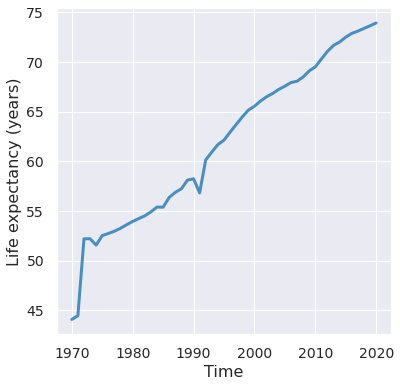

In [13]:
bgd_life_expectancy = life_expectancy.where("Time",are.above_or_equal_to(1970)).where("Geo",are.equal_to("bgd")).drop("Geo")
bgd_life_expectancy
bgd_life_expectancy_plot = bgd_life_expectancy.plot("Time","Life expectancy (years)")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

#### Part 1.4 (5 pts)


 Assuming everything else stays the same, do the trends in life expectancy in the graph above directly explain why the population growth rate decreased from 1985 to 2015 in Bangladesh? Why or why not? 

*Hint:* What happened in Bangladesh in 1991, and does that event explain the overall change in population growth rate? This [webpage](https://en.wikipedia.org/wiki/1991_Bangladesh_cyclone) provides relevant context.



<hr style="margin:0; border: 1px solid #FFBE0A;"/><font color='#FFBE0A'>Written Answer:</font>

The trends in life expectancy do not explain why the population growth rate decreased from 1985 to 2015 in Bangladesh, because we still observe a steady increase in life expectancy within that period, despite the fall in population growth rate. This can be accounted for by the 1991 Bangladesh Tropical Cyclone that caused at least 138,866 deaths drastically reducing the Population Growth rate of Bangladesh. But this event can only be held accountable for the drop in the Population growth rate as from 1991, which means there are probably other factors which could have led to a fall in the Population Growth of Bangladesh before that year.

<hr style="margin:0; border: 1px solid #FFBE0A;"/>

<!-- END QUESTION -->

#### Part 1.5 (5 pts)


The `fertility` table contains a statistic that is often used to measure how many babies are being born, the *total fertility rate*. This number describes the [number of children a woman would have in her lifetime](https://www.measureevaluation.org/prh/rh_indicators/specific/fertility/total-fertility-rate), on average, if the current rates of birth by age of the mother persisted throughout her child bearing years, assuming she survived through age 49. 

For this part, complete the function `fertility_over_time`. The function has two parameters: 
 - `country_code`: an Alpha-3 code of a country
 - `start`: the start year of the returned table (inclusive) 
 
The function returns a two-column table with labels `Year` and `Children per woman` with the country's fertility rate each year, starting at the `start` year (it should include all later years that appear in the `fertility` table). 

After you've written the function, use the provided code  to plot how Bangladesh's fertility rate has changed since 1970. **The expression that draws the line plot is provided for you; please don't change it.**

*Note:* The function `fertility_over_time` should return a table, not the plot itself. 

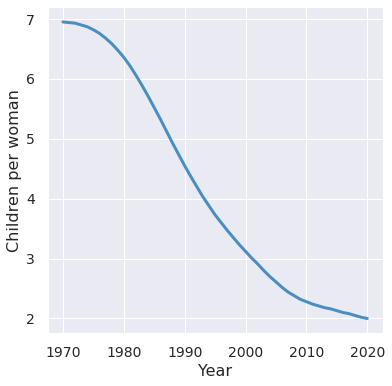

In [14]:
def fertility_over_time(country_code, start):
    # Return a two-column table that describes a country's total fertility rate each year.
    return fertility.where("Geo", are.equal_to(country_code)).where("Time", are.above_or_equal_to(start)).drop("Geo").relabeled("Time", "Year")

fertility_over_time('bgd', 1970).plot('Year', 'Children per woman') # You should *not* change this line.

In [15]:
grader.check("p1.5")

✅ p1.5.1: check(fertility_over_time('usa', 2010).labels == ('Year', 'Children per woman'))
✅ p1.5.2: check(fertility_over_time('usa', 2010).column('Year') == np.arange(2010, 2021))
✅ p1.5.3: check(fertility_over_time('usa', 2005).column('Year') == np.arange(2005, 2021))

<!-- BEGIN QUESTION -->

#### Part 1.6 (5 pts)


 Assuming everything else is constant, do the trends in fertility in the graph above help explain why the population growth rate decreased from 1980 to 2020 in Bangladesh? Why or why not?



<hr style="margin:0; border: 1px solid #FFBE0A;"/><font color='#FFBE0A'>Written Answer:</font>

Yes, it actually does. The fertility over time plot showcases an exponential decrease in the fertility (children born per woman) from 1980 to 2020, which is a factor that potentially led to the fall of the Population Growth rate of Bangladesh, especially before the 1991 Tropical Cyclone.

<hr style="margin:0; border: 1px solid #FFBE0A;"/>

<!-- END QUESTION -->

#### Part 1.7 (5 pts)


It has been [observed](https://www.ageing.ox.ac.uk/download/143) that lower fertility rates are often associated with lower child mortality rates. The link has been attributed to family planning: if parents can expect that their children will all survive into adulthood, then they will choose to have fewer children. In the reverse direction, having fewer children may allow families to devote more resources to each child, reducing child mortality. We can see if this association is evident in Bangladesh by plotting the relationship between total fertility rate and [child mortality rate per 1000 children](https://en.wikipedia.org/wiki/Child_mortality).

Using both the `fertility` and `child_mortality` tables, we will draw a scatter diagram that has Bangladesh's total fertility on the horizontal axis and its child mortality on the vertical axis with one point for each year, starting with 1970.

**The code that draws the scatter diagram is provided for you; please don't change it.** 

For your part, create a table called `post_1969_fertility_and_child_mortality` with the appropriate column labels and data in order to generate the chart correctly. Use the label `Children per woman` to describe total fertility and the label `Child deaths per 1000 born` to describe child mortality.  Your table should also have a `Time` column.

*Note*: Do not drop the `Time` column or you will get an error in the scatterplot in the next cell!

In [16]:
fertility.show(3)

Geo,Time,Children per woman
abw,1800,5.64
abw,1801,5.64
abw,1802,5.64


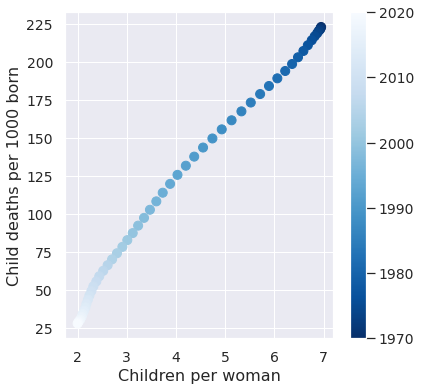

In [17]:
bgd_post_1969_fertility = fertility.where("Geo", are.equal_to("bgd")).where("Time", are.between_or_equal_to(1970,2020)).drop("Geo")
bgd_post_1969_child_mortality = child_mortality.where("Geo", are.equal_to("bgd")).where("Time", are.between_or_equal_to(1970,2020)).drop("Geo")
post_1969_fertility_and_child_mortality = bgd_post_1969_fertility.join("Time", bgd_post_1969_child_mortality)
post_1969_fertility_and_child_mortality

# Don't change anything below this line!
x_births = post_1969_fertility_and_child_mortality.column('Children per woman')
y_deaths = post_1969_fertility_and_child_mortality.column('Child deaths per 1000 born')
time_colors = post_1969_fertility_and_child_mortality.column('Time')

import matplotlib.pyplot as plots
plots.figure(figsize=(6,6))
plots.scatter(x_births, y_deaths, c=time_colors, cmap="Blues_r")
plots.colorbar()
plots.xlabel('Children per woman')
plots.ylabel('Child deaths per 1000 born');

In [18]:
grader.check("p1.7")

✅ p1.7.1: check('Child deaths per 1000 born' in post_1969_fertility_and_child_mortality.labels)
✅ p1.7.2: check('Children per woman' in post_1969_fertility_and_child_mortality.labels)
✅ p1.7.3: check(post_1969_fertility_and_child_mortality.num_rows == 51)

The plot above uses **color** to encode data about the `time` column from the table `post_1969_fertility_and_child_mortality`. The colors, ranging from dark blue to white, represent the passing of time between the 1970s to the 2020s. For example, a point on the scatter plot representing data from the 1970s would appear as **dark blue** and a point from the 2010s would appear as **light blue**.


<!-- BEGIN QUESTION -->

#### Part 1.8 (5 pts)


 In one or two sentences, describe the association (if any) that is illustrated by this scatter diagram. Does the diagram show that reduced child mortality *causes* parents to choose to have fewer children?



<hr style="margin:0; border: 1px solid #FFBE0A;"/><font color='#FFBE0A'>Written Answer:</font>

From the scatter plot, there is a direct relationship between child mortality and fertility in Bangladesh over time. This means that reduced child mortality causes parents in Bangladesh to have fewer chidren.


<hr style="margin:0; border: 1px solid #FFBE0A;"/>

<!-- END QUESTION -->

### Checkpoint

Congratulations, you have reached the checkpoint!  Follow these steps to submit your work:
* Run the tests and verify that they pass as you expect, and that all images/graphs appear in the output.
* Choose **Save Notebook** from the **File** menu.
* **Run the following cell** and click the link below to download the zip file. 

Once you have downloaded that file, go to [Gradescope](https://www.gradescope.com/) and submit the zip file to the assignment is "Project 1 Checkpoint".

In [19]:
# Save your notebook first, then run this cell to export your submission.
grader.export(pdf=True)

Output()

<hr style="margin-bottom: 0px; padding:0; border: 2px solid #500082;"/>


## 2. Population Growth: The World (45 pts)


The change observed in Bangladesh since 1970 can also be observed in many other developing countries: health services improve, life expectancy increases, and child mortality decreases. At the same time, the fertility rate often plummets, and so the population growth rate decreases despite increasing longevity.

Run the cell below to generate two overlaid histograms, one for 1960 and one for 2010, that show the distributions of total fertility rates for these two years among all 201 countries in the `fertility` table.

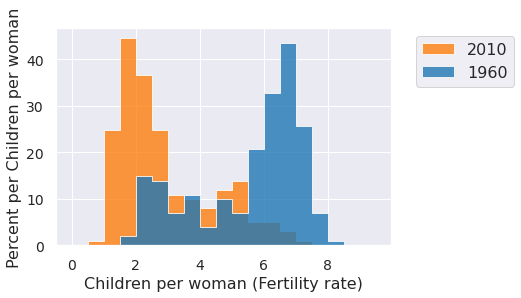

In [20]:
fertility_1960_2010 = Table().with_columns(
    '1960', fertility.where('Time', 1960).column('Children per woman'),
    '2010', fertility.where('Time', 2010).column('Children per woman')
)
plot = fertility_1960_2010.hist(bins=np.arange(0, 10, 0.5), unit='Children per woman')
plot.set_xlabel('Children per woman (Fertility rate)')

#### Part 2.1 (4 pts)


Using the histogram above, please answer the following two questions:

1. In 2010, roughly what percent of countries had a fertility rate between 1.5 and 2?
2. In 1960, roughly what percent of countries had a fertility rate below 3?

Assign your answers to the variables `percent_2010` and `percent_1960` below.  They need not be exact, but simply a reasonable estimate based on you reading the histogram properly.

In [21]:
percent_2010 = 22
percent_1960 = 11

In [22]:
grader.check("p2.1")

✅ p2.1.1: check(0 <= percent_2010 <= 100)
✅ p2.1.2: check(0 <= percent_1960 <= 100)

<!-- BEGIN QUESTION -->

#### Part 2.2 (4 pts)


Describe the most striking distinction you see between fertility rates in 1960 and 2010?  In one or two sentences, quantify that distinction using the data presented in the histogram above.

<hr style="margin:0; border: 1px solid #FFBE0A;"/><font color='#FFBE0A'>Written Answer:</font>

The fertiity rate of 2010 is smaller compared to the fertility rate in 1960. This is observed from the fact that a higher percentage of women gave birth to 6 to 7 children in 1960 (where we have the peak in the 1960 histogram) while a grater percentage of women gave birth to 1 to 3 children in the 2010 (where we have the peak in the 2010) histogram.


<hr style="margin:0; border: 1px solid #FFBE0A;"/>

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

#### Part 2.3 (5 pts)


Create line graph of the world population from 1800 through 2020 (inclusive of both endpoints). The world population is the sum of all of the countries' populations. You should use the `population` table defined earlier in the project. 



Time,World Population
1800,984198691
1801,987628322
1802,991098738
1803,994610260
1804,998163240


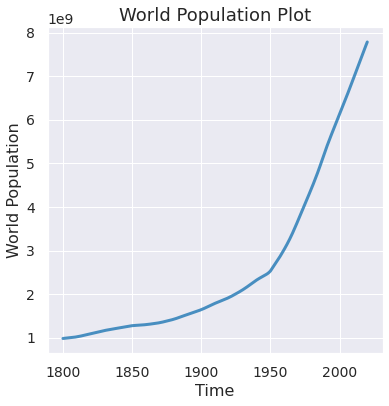

In [23]:
#Fill in code here
world_population_per_year = population.drop("Geo").group("Time", sum).relabeled("Population sum","World Population")
world_population_per_year.show(5)
world_population_plot = world_population_per_year.plot("Time","World Population", title="World Population Plot")

<!-- END QUESTION -->

#### Part 2.4 (5 pts)


 Create a function `stats_for_year` that takes a `year` as a parameter and returns a table of statistics.
 
 The table it returns should have four columns: 
 - `Geo`
 - `Population`
 - `Children per woman`
 - `Child deaths per 1000 born`
in that order. 

Each row should contain one unique Alpha-3 country code and three statistics: population, fertility rate, and child mortality for that `year` from the `population`, `fertility` and `child_mortality` tables. Only include rows for which all three statistics are available for the country and year.

In addition, restrict the result to country codes that appears in `big_50`, an array of the 50 most populous countries in 2020. This restriction will speed up computations later in the project.

After you write `stats_for_year`, try calling `stats_for_year` on any year between 1960 and 2020. Look at the output of `stats_for_year` and see if you can make sense of it.

*Hint*: The tests for this question are quite comprehensive, so if you pass the tests, your function is probably correct. However, without calling your function yourself and looking at the output, it will be very difficult to understand any problems you have, so try your best to write the function correctly and check that it works before you rely on the `grader` tests to confirm your work.

*Hint*: What do all three tables have in common (pay attention to column names)?

In [24]:
# We first create a population table that only includes the 
# 50 countries with the largest 2020 populations. We focus on 
# these 50 countries only so that plotting later will run faster.
big_50 = population.where('Time', are.equal_to(2020)).sort('Population', descending=True).take(np.arange(50)).column('Geo')
population_of_big_50 = population.where('Time', are.above_or_equal_to(1960)).where('Geo', are.contained_in(big_50))

def stats_for_year(year):
    """Return a table of the stats for each country in big_50 for that year."""
    p = population_of_big_50.where('Time', are.equal_to(year)).drop('Time')
    f = fertility.where('Time', are.equal_to(year)).drop('Time').where('Geo', are.contained_in(big_50))
    c = child_mortality.where('Time', are.equal_to(year)).drop('Time').where('Geo', are.contained_in(big_50))
    return p.join("Geo",f).join("Geo",c)

stats_for_year(2020)  

Geo,Population,Children per woman,Child deaths per 1000 born
afg,38928341,4.04,58.08
ago,32866268,5.41,72.29
arg,45195777,2.23,9.4
bgd,164689383,2,27.7
bra,212559409,1.67,13.47
can,37742157,1.56,4.89
chn,1439323774,1.65,8.09
cod,89561404,5.72,84.53
col,50882884,1.78,13.48
deu,83783945,1.49,3.24


In [25]:
grader.check("p2.4")

✅ p2.4.1: check(stats_for_year(1990).labels == ('Geo', 'Population', 'Children per woman', 'Child deaths per 1000 born'))
✅ p2.4.2: check(stats_for_year(1990).num_rows == 50)
✅ p2.4.3: check(stats_for_year(1960).sort('Geo').column('Geo').item(49) == 'zaf')
✅ p2.4.4: check(stats_for_year(2010).sort('Geo').take(np.arange(3, 50, 5)).column('Geo') == ['bgd', 'col', 'eth', 'ind', 'ken', 'moz', 'per', 'sdn', 'ukr', 'yem'])

#### Part 2.5 (5 pts)


In the next two question parts, we will build up to creating a table with the world population for the first year of each decade. 

First, create a helper function `pop_for_year` that computes the total population per year for all countries in the `big_50` table defined above. 

*Hint:* Your answer should use the `stats_for_year` function from the previous question.

In [26]:
def pop_for_year(year):
    """Return the total population for the specified year."""
    pop = stats_for_year(year)
    return sum(pop.column("Population"))


In [27]:
grader.check("p2.5")

✅ p2.5.1: check(pop_for_year(1972) == 3355562066)
✅ p2.5.2: check(pop_for_year(2020) == 6765161289)
✅ p2.5.3: check(pop_for_year(1989) == 4576679948)
✅ p2.5.4: check(pop_for_year(2002) == 5514129422)

#### Part 2.6 (5 pts)


Now that you've defined your helper function, create a table called `pop_by_decade` with two columns called `Decade` and `Population`, in that order. 

The `pop_by_decade` table should have a row for each year that starts a decade, in increasing order starting with 1960 and ending with 2020. For example, 1960 is the start of the 1960's decade. 

Within the `pop_by_decade` table, the `Population` column should contain the total population of all countries included in the result of `stats_for_year(year)` for the first `year` of the decade. You should see that these countries contain most of the world's population.

*Hint:* `.apply()` might be helpful here. 

In [28]:
# Table with the years starting each decade
decades = Table().with_column('Decade', np.arange(1960, 2021, 10))
                      
pop_by_decade = decades.with_columns("Population",decades.apply(pop_for_year,"Decade"))
pop_by_decade.set_format(1, NumberFormatter) #Make the numbers have ,'s for readability.
pop_by_decade

Decade,Population
1960,"2,635,123,897"
1970,"3,221,457,416"
1980,"3,890,044,418"
1990,"4,656,339,803"
2000,"5,377,062,169"
2010,"6,064,674,132"
2020,"6,765,161,289"


In [29]:
grader.check("p2.6")

✅ p2.6.1: check(pop_by_decade.labels == ('Decade', 'Population'))
✅ p2.6.2: check(pop_by_decade.column(0).item(0) == 1960)

#### Part 2.7 (5 pts)


The `countries` table below describes various characteristics of countries. The `Country` column contains the same codes as the `Geo` column in each of the other data tables (`population`, `fertility`, and `child_mortality`). The `World6 region` column classifies each country into a region of the world. Run the cell below to inspect the data.

In [30]:
countries = Table.read_table('countries.csv')
countries = countries.select('Country', 'Name', 'World6 region')
countries

Country,Name,World6 region
abw,Aruba,america
afg,Afghanistan,south_asia
ago,Angola,sub_saharan_africa
aia,Anguilla,america
ala,Åland,europe_central_asia
alb,Albania,europe_central_asia
and,Andorra,europe_central_asia
are,United Arab Emirates,middle_east_north_africa
arg,Argentina,america
arm,Armenia,europe_central_asia


 Create a table called `region_counts`. It should contain two columns called `region` and `count`. The `region` column should contain regions of the world, and the `count` column should contain the number of countries in each region that appears in the result of `stats_for_year(2020)`. 

For example, one row would have `south_asia` as its `region` value and an integer as its `count` value: the number of large South Asian countries for which we have population, fertility, and child mortality numbers from 2020.

*Hint*: You may have to relabel a column to name it `region`. 



In [31]:
stats_for_2020 = stats_for_year(2020)

region_counts = countries.join("Country",stats_for_2020,"Geo").relabeled("World6 region","region").select("region").group("region")
region_counts

region,count
america,8
east_asia_pacific,9
europe_central_asia,10
middle_east_north_africa,7
south_asia,5
sub_saharan_africa,11


In [32]:
grader.check("p2.7")

✅ p2.7.1: check(region_counts.labels == ('region', 'count'))
✅ p2.7.2: check(sum(region_counts.column('count')) == 50)

<!-- BEGIN QUESTION -->

#### Part 2.8 (3 pts)


The following scatter diagram compares total fertility rate and child mortality rate for each country in 1960. The area of each dot represents the population of the country, and the color represents its region of the world. Run the cell. Do you think you can identify any of the dots?

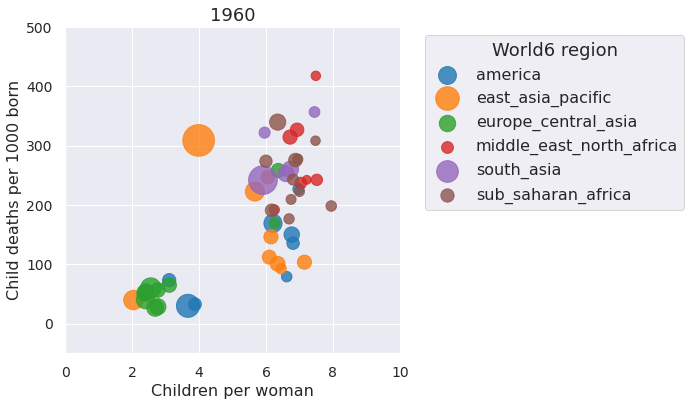

In [33]:
def fertility_vs_child_mortality(year):
    """Draw a color scatter diagram comparing child mortality and fertility."""
    with_region = stats_for_year(year).join('Geo', countries.select('Country', 'World6 region'), 'Country')
    plot = with_region.scatter('Children per woman', 
                        'Child deaths per 1000 born', 
                        sizes='Population', 
                        group='World6 region', 
                        s=500)
    plot.set_xlim(0,10)
    plot.set_ylim(-50, 500)
    plot.set_title(year)

fertility_vs_child_mortality(1960)

As a whole, which region had the lowest child mortality rate?  Justify your answer in one sentence using the scatter plot above.

<hr style="margin:0; border: 1px solid #FFBE0A;"/><font color='#FFBE0A'>Written Answer:</font>

Overall, the Europe Central Asia region has the lowest child mortality rate. From the scatter plot, we observe that most of the countries in the Europe Central Asia region are clustered between zero to a hundred child deaths per 1000 born, compared to the other regions.

<hr style="margin:0; border: 1px solid #FFBE0A;"/>

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

#### Part 2.9 (3 pts)


Complete this statement: "Most regions have a fertility rate above ...".  Justify your answer in one sentence using the scatter plot above.

<hr style="margin:0; border: 1px solid #FFBE0A;"/><font color='#FFBE0A'>Written Answer:</font>

6 chidren per woman. The countries of most of the regions are clustered above 6 on the Children per woman axis, implying that most regions have a fertility rate above 6.


<hr style="margin:0; border: 1px solid #FFBE0A;"/>

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

#### Part 2.10 (3 pts)


Is there any association between child mortality and fertility? Why? Is it causal?

<hr style="margin:0; border: 1px solid #FFBE0A;"/><font color='#FFBE0A'>Written Answer:</font>

There is an association between child mortality and fertility, because we can draw a diagonal line passing through most of the dots, portraying a direct relationship between child mortality and fertility. This association is  causal in both directions, meaning if couples can expect that their children will all survive into adulthood, then they will choose to have fewer children. In the reverse direction, having fewer children may allow families to devote more resources to each child, reducing child mortality.

<hr style="margin:0; border: 1px solid #FFBE0A;"/>

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

#### Part 2.11 (3 pts)


Is there any relationship between the largest countries by population and the child mortality rates?  Justify your answer in one sentence using the scatter plot above.

<hr style="margin:0; border: 1px solid #FFBE0A;"/><font color='#FFBE0A'>Written Answer:</font>

There is no relationship between largest countries by population and child mortality rates. The countries with the largest population sizes are randomly dispersed on the scatter plot, indicating no concise relationship between the two factors.

<hr style="margin:0; border: 1px solid #FFBE0A;"/>

<!-- END QUESTION -->

### Visualizing Changes Over Time

The result of the cell below is interactive. Drag the slider to the right to see how countries have changed over time. You'll find that the great divide between so-called "Western" and "developing" countries that existed in the 1960's has nearly disappeared. This shift in fertility rates is the reason that the global population is expected to grow more slowly in the 21st century than it did in the 19th and 20th centuries.

In [34]:
interact(fertility_vs_child_mortality, year=Slider(1960, 2020))

interactive(children=(IntSlider(value=1990, description='year', max=2020, min=1960), Output()), _dom_classes=(…

Now is a great time to take a break and watch the same data presented by [Hans Rosling in a 2010 TEDx talk](https://www.gapminder.org/videos/reducing-child-mortality-a-moral-and-environmental-imperative) with smoother animation and witty commentary.

<hr style="margin-bottom: 0px; padding:0; border: 2px solid #500082;"/>


## 3. Global Poverty (35 pts)



In 1800, 85% of the world's 1 billion people lived in [extreme poverty](https://en.wikipedia.org/wiki/Extreme_poverty), defined by the United Nations as "a condition characterized by severe deprivation of basic human needs, including food, safe drinking water, sanitation facilities, health, shelter, education and information." At the time when the data in this project were gathered, a common definition of extreme poverty was a person living on less than \$1.25 a day.

In 2018, the proportion of people living in extreme poverty was estimated to be [about 9\%](https://unstats.un.org/sdgs/report/2019/goal-01/). Although the world rate of extreme poverty has declined consistently for hundreds of years, the number of people living in extreme poverty is still over 600 million. The United Nations adopted an [ambitious goal](http://www.un.org/sustainabledevelopment/poverty/): "By 2030, eradicate extreme poverty for all people everywhere." In this part of the project we will examine aspects of global poverty that might affect whether the goal is achievable.

First, load the population and poverty rate by country and year and the country descriptions. While the `population` table has values for every recent year for many countries, the `poverty` table only includes certain years for each country in which a measurement of the rate of extreme poverty was available.

In [35]:
population = Table.read_table('population.csv')
countries = Table.read_table('countries.csv')
poverty = Table.read_table('poverty.csv')
poverty.show(3)

Geo,Time,Poverty percent
alb,1996,0.2
alb,2002,0.73
alb,2004,0.53


In [36]:
countries.show(3)
population.show(3)

Country,Name,World6 region,World4 region,Latitude,Longitude
abw,Aruba,america,americas,12.5,-69.9667
afg,Afghanistan,south_asia,asia,33,66
ago,Angola,sub_saharan_africa,africa,-12.5,18.5


Geo,Time,Population
afg,1800,3280000
afg,1801,3280000
afg,1802,3280000


#### Part 3.1 (5 pts)


 Assign `latest_poverty` to a three-column table with one row for each country that appears in the `poverty` table. 
 - The first column should contain the 3-letter code for the country. 
 - The second column should contain the most recent year for which an extreme poverty rate is available for the country. 
 - The third column should contain the poverty percent in that year. 
 
**Do not change the last line, so that the labels of your table are set correctly.**

*Hint*: It will be useful to keep in mind how ```group``` works: it searches the table from top to bottom, collecting values in the order in which they appear.  It then applies the aggregation function to an array containing those values in the order in which they were found.  Thus, the first item in the array passed to the aggregation function corresponds to the first row found that is part of the group being processed.  The `first` function may be helpful, provided you sort the table appropriately before grouping...

In [37]:
def first(values):
    return values.item(0)

latest_poverty = poverty.sort("Time",descending=True).group("Geo", first)
latest_poverty

# You should *not* change this line.
latest_poverty = latest_poverty.relabeled(1, 'Time').relabeled(2, 'Poverty percent') 
latest_poverty

Geo,Time,Poverty percent
ago,2009,43.37
alb,2012,0.46
arg,2011,1.41
arm,2012,1.75
aus,2003,1.36
aut,2004,0.34
aze,2008,0.31
bdi,2006,81.32
bel,2000,0.5
ben,2012,51.61


In [38]:
grader.check("p3.1")

✅ p3.1.1: check(latest_poverty.labels == ('Geo', 'Time','Poverty percent'))
✅ p3.1.2: check(latest_poverty.num_rows == 145)

#### Part 3.2 (5 pts)


 Using both `latest_poverty` and `population`, create a four-column table called `recent_poverty_total` with one row for each country in `latest_poverty`. The four columns should have the following labels and contents:
1. `Geo` contains the 3-letter country code,
1. `Poverty percent` contains the poverty percentage for the most recent year we have available,
1. `Population` contains the population of the country in 2010,
1. `Poverty total` contains the number of people in poverty **rounded to the nearest integer**, based on the 2010 population and most recent poverty rate.


In [39]:
pop_2010 = population.where("Time", are.equal_to(2010)).drop("Time")
poverty_pop = latest_poverty.drop("Time").join("Geo",pop_2010,"Geo")
poverty_pop
poverty_total_array = np.round(((poverty_pop.column("Poverty percent"))*(poverty_pop.column("Population")))/100)
recent_poverty_total = poverty_pop.with_column("Poverty total", poverty_total_array)
recent_poverty_total

Geo,Poverty percent,Population,Poverty total
ago,43.37,23356247,1.01296e+07
alb,0.46,2948029,13561
arg,1.41,40895751,576630
arm,1.75,2877314,50353
aus,1.36,22154687,301304
aut,0.34,8409945,28594
aze,0.31,9032465,28001
bdi,81.32,8675606,7.055e+06
bel,0.5,10938735,54694
ben,51.61,9199254,4.74774e+06


In [40]:
grader.check("p3.2")

✅ p3.2.1: check(recent_poverty_total.labels==('Geo','Poverty percent','Population','Poverty total'))
✅ p3.2.2: check(recent_poverty_total.where('Geo',are.equal_to('aus')).column('Population').item(0) == 22154687)
✅ p3.2.3: check(recent_poverty_total.where('Geo', 'aus').column('Poverty total').item(0) == approx(301304))

#### Part 3.3 (5 pts)


 Assign the variable `poverty_percent` to the known percentage of the world’s 2010 population that were living in extreme poverty.
 
 
Assume that the `poverty_total` numbers in the `recent_poverty_total` table describe **all** people in 2010 living in extreme poverty. You should get a number that is above the 2018 global estimate of 9%, since many country-specific poverty rates are older than 2018.

*Hints*: 
* Break this up into multiple lines to make it easier to debug.
* The sum of the `Population` column in the `recent_poverty_total` table is not the world population, because only a subset of the world's countries are included in this `recent_poverty_total` table (only some countries have known poverty rates). Use the `population` table to compute the world's 2010 total population.
* We are computing a percentage (value between 0 and 100), not a proportion (value between 0 and 1).


In [41]:
poverty_total = sum(recent_poverty_total.column("Poverty total"))
total_pop_2010 = sum(pop_2010.column("Population"))

poverty_percent = (poverty_total/total_pop_2010)*100
poverty_percent

14.248865303997139

In [42]:
grader.check("p3.3")

✅ p3.3.1: check(10 <= poverty_percent <= 20)

#### Part 3.4 (5 pts)


The `countries` table includes not only the name and region of countries, but also their positions on the globe.  

*Note*: We're using the World4 region desigation in the following parts.  This is a coarser designation that the World6 designation used above.  It places countries in one of four regions: `americas`, `africa`, `europe`, or `asia`.

In [43]:
countries.select('Country', 'Name', 'World4 region', 'Latitude', 'Longitude')

Country,Name,World4 region,Latitude,Longitude
abw,Aruba,americas,12.5,-69.9667
afg,Afghanistan,asia,33,66
ago,Angola,africa,-12.5,18.5
aia,Anguilla,americas,18.2167,-63.05
ala,Åland,europe,60.25,20
alb,Albania,europe,41,20
and,Andorra,europe,42.5078,1.52109
are,United Arab Emirates,asia,23.75,54.5
arg,Argentina,americas,-34,-64
arm,Armenia,europe,40.25,45


 Using both `countries` and `recent_poverty_total`, create a five-column table called `poverty_map` with one row for every country in `recent_poverty_total`.  The five columns should have the following labels and contents:
1. `Latitude` contains the country's latitude,
1. `Longitude` contains the country's longitude,
1. `Name` contains the country's name,
1. `Region` contains the country's region from the `World4 region` column of `countries`,
1. `Poverty total` contains the country's poverty total.

*Hint:*  Be sure to put the columns in the order specified.  You may find it useful to remember that that a call to `table.select(...)` puts columns in the order that they are specified as parameters in the call to select.

In [44]:
recent_poverty_total_updated = recent_poverty_total.select("Geo","Poverty total")
poverty_map = countries.join("Country",recent_poverty_total_updated,"Geo").relabeled("World4 region","Region").select("Latitude","Longitude","Name","Region","Poverty total")
poverty_map

Latitude,Longitude,Name,Region,Poverty total
-12.5,18.5,Angola,africa,1.01296e+07
41,20,Albania,europe,13561
-34,-64,Argentina,americas,576630
40.25,45,Armenia,europe,50353
-25,135,Australia,asia,301304
47.3333,13.3333,Austria,europe,28594
40.5,47.5,Azerbaijan,europe,28001
-3.5,30,Burundi,africa,7.055e+06
50.75,4.5,Belgium,europe,54694
9.5,2.25,Benin,africa,4.74774e+06


In [45]:
grader.check("p3.4")

✅ p3.4.1: check(poverty_map.labels == ('Latitude','Longitude','Name','Region','Poverty total'))
✅ p3.4.2: check(np.sort(np.unique(poverty_map.column('Region'))) == ['africa', 'americas', 'asia', 'europe'])

Run the cell below to draw a map of the world in which the areas of circles represent the number of people living in extreme poverty. Double-click on the map to zoom in.

In [46]:
# It may take a few seconds to generate this map.
colors = {'africa': 'blue', 'europe': 'black', 'asia': 'red', 'americas': 'green'}
scaled = poverty_map.with_columns(
    'labels', poverty_map.column('Name'),
    'colors', poverty_map.apply(colors.get, 'Region'),
    'areas', 1e-4 * poverty_map.column('Poverty total')
).drop('Name', 'region', 'Poverty total')

Circle.map_table(scaled)

Although people lived in extreme poverty throughout the world in 2010 (with more than 5 million in the United States), the largest numbers were in Asia and Africa.

#### Part 3.5 (5 pts)


 Assign `largest` to a two-column table with columns `Name` (not the 3-letter code) and `Poverty total` of the 10 countries with the largest number of people living in extreme poverty.

*Hint*: How can we use `take` and `np.arange` in conjunction with each other?

In [47]:
...
largest = poverty_map.select("Name","Poverty total").sort("Poverty total", descending=True).take(np.arange(0,10))
largest

# Do not change the following line. It makes the table view more readable. 
largest.set_format('Poverty total', NumberFormatter)

Name,Poverty total
India,"291,660,639.00"
Nigeria,"98,319,537.00"
China,"85,687,544.00"
Bangladesh,"63,826,375.00"
"Congo, Dem. Rep.","56,635,412.00"
Indonesia,"39,177,145.00"
Ethiopia,"32,242,742.00"
Pakistan,"22,858,700.00"
Tanzania,"19,281,872.00"
Madagascar,"18,543,643.00"


In [48]:
grader.check("p3.5")

✅ p3.5.1: check(largest.labels == ('Name', 'Poverty total'))
✅ p3.5.2: check(largest.column('Name').item(0) == 'India')
✅ p3.5.3: check(largest.num_rows == 10)

<!-- BEGIN QUESTION -->

#### Part 3.6 (5 pts)


It is important to study the absolute number of people living in poverty, not just the percent. The absolute number is an important factor in determining the amount of resources needed to support people living in poverty. 

To do that, we'll now write a function called `poverty_timeline` that takes **the name of a country** (not the geo code) as its argument. The function should draw a line graph of the number of people living in poverty in that country with time on the horizontal axis. The line graph should have a point for each row in the `poverty` table for that country. 

*Hints:*
- To compute the population living in poverty from a poverty percentage, multiply by the population of the country **in that year**.
- To make your plot, you will first need to make a table.
- Feel free to use the `country_name_to_geo` function we provided for you. 
- This question is more involved than other parts. Feel free to create cells and experiment. You can create cells by going to the toolbar and hitting the `+` button.


In [49]:
recent_poverty_total.show(3)
population.show(3)

Geo,Poverty percent,Population,Poverty total
ago,43.37,23356247,1.01296e+07
alb,0.46,2948029,13561
arg,1.41,40895751,576630


Geo,Time,Population
afg,1800,3280000
afg,1801,3280000
afg,1802,3280000


In [50]:
def country_name_to_geo(country_name):
    """Compute the geo code for the given country name."""
    country_col = countries.where('Name', are.equal_to(country_name)).column('Country')
    assert len(country_col) > 0, 'Country ' + country_name + ' could not be found.'
    return country_col.item(0)

def poverty_timeline(country_name):
    '''Draw a timeline of people living in extreme poverty in a country.'''
    geo = country_name_to_geo(country_name)
    # This solution will take multiple lines of code. Use as many as you need.
    pop_poverty = population.where("Geo",are.equal_to(geo)).drop("Geo")
    poverty_pop_array = np.round((poverty_percent/100)*pop_poverty.column("Population"))
    poverty = pop_poverty.with_column("Poverty population",poverty_pop_array).drop("Population")
    print(poverty)
    plot = poverty.plot("Time","Poverty population")
    # Don't change anything below this line. 
    plot.set_title(country_name)
    plot.set_ylim(0)
    return plot 
    

Time | Poverty population
1800 | 42747
1801 | 42871
1802 | 42996
1803 | 43122
1804 | 43248
1805 | 43374
1806 | 43500
1807 | 43627
1808 | 43755
1809 | 43882
... (291 rows omitted)


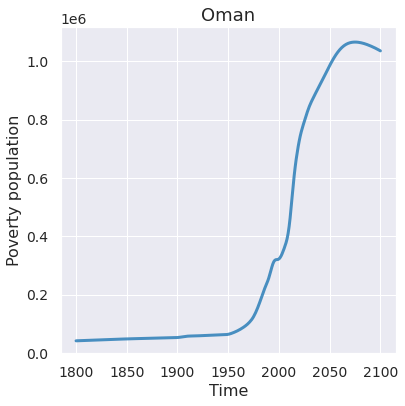

In [51]:
poverty_timeline('Oman')

Time | Poverty population
1800 | 2.86022e+07
1801 | 2.86586e+07
1802 | 2.87151e+07
1803 | 2.87717e+07
1804 | 2.88284e+07
1805 | 2.88853e+07
1806 | 2.89422e+07
1807 | 2.89993e+07
1808 | 2.90565e+07
1809 | 2.91138e+07
... (291 rows omitted)


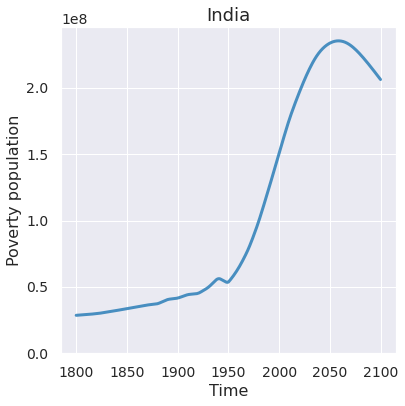

In [52]:
poverty_timeline('India')  # sample call

<!-- END QUESTION -->

Finally, draw the line plots below to see how the world is changing. Pay attention to the axes! You can check your work by comparing your graphs to the ones on [gapminder.org](https://www.gapminder.org/tools/#$state$entities$show$country$/$in@=ind;;;;&marker$axis_y$which=number_of_people_in_poverty&scaleType=linear&spaceRef:null;;;&chart-type=linechart).



Time | Poverty population
1800 | 2.86022e+07
1801 | 2.86586e+07
1802 | 2.87151e+07
1803 | 2.87717e+07
1804 | 2.88284e+07
1805 | 2.88853e+07
1806 | 2.89422e+07
1807 | 2.89993e+07
1808 | 2.90565e+07
1809 | 2.91138e+07
... (291 rows omitted)
Time | Poverty population
1800 | 1.72424e+06
1801 | 1.72424e+06
1802 | 1.72424e+06
1803 | 1.72424e+06
1804 | 1.72424e+06
1805 | 1.72424e+06
1806 | 1.72424e+06
1807 | 1.72424e+06
1808 | 1.72424e+06
1809 | 1.72424e+06
... (291 rows omitted)
Time | Poverty population
1800 | 4.70213e+07
1801 | 4.72405e+07
1802 | 4.74609e+07
1803 | 4.76822e+07
1804 | 4.79046e+07
1805 | 4.8128e+07
1806 | 4.83524e+07
1807 | 4.85779e+07
1808 | 4.88045e+07
1809 | 4.90321e+07
... (291 rows omitted)
Time | Poverty population
1800 | 171841
1801 | 171841
1802 | 171841
1803 | 171841
1804 | 171841
1805 | 171841
1806 | 171841
1807 | 171841
1808 | 171841
1809 | 171841
... (291 rows omitted)
Time | Poverty population
1800 | 854932
1801 | 871145
1802 | 887665
1803 | 904498
1804 | 921651

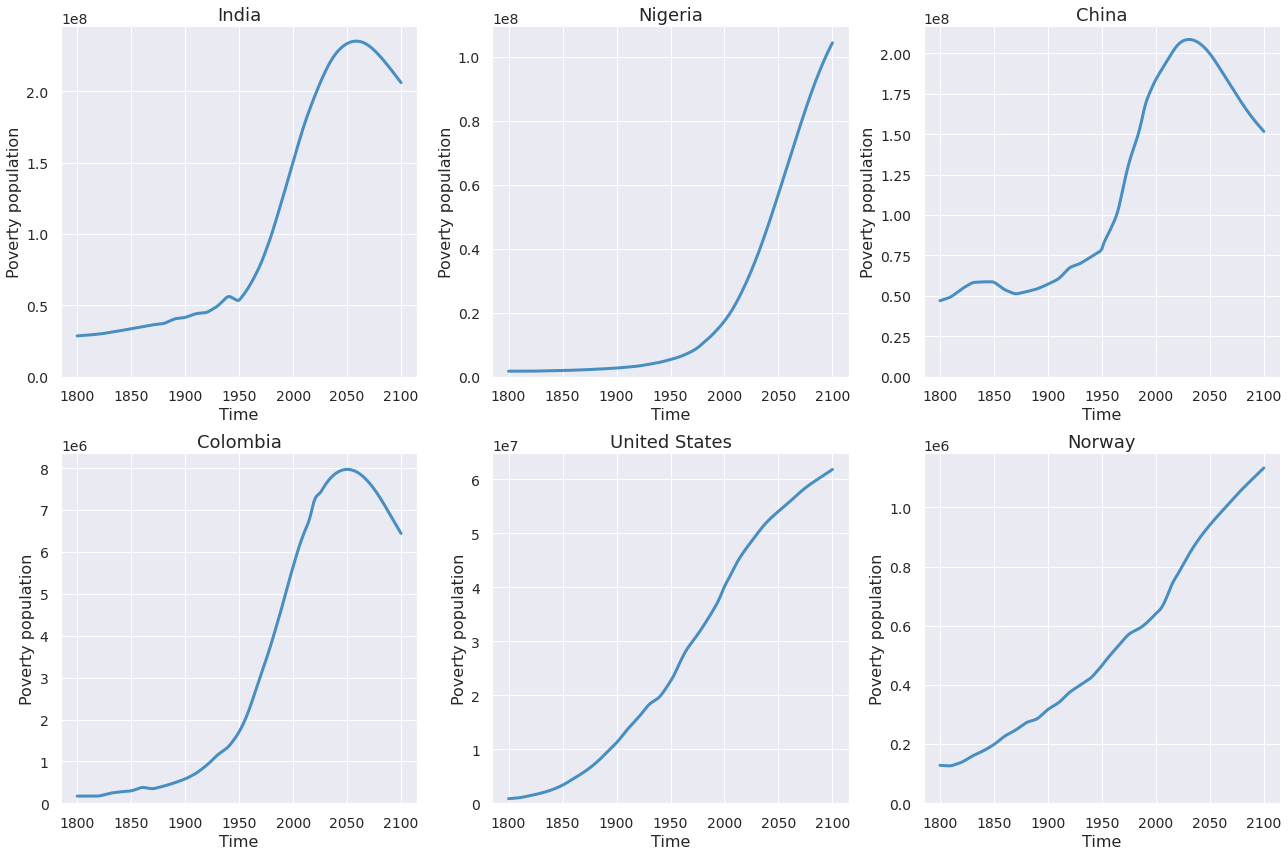

In [53]:
with Figure(2,3):
    poverty_timeline('India')
    poverty_timeline('Nigeria')
    poverty_timeline('China')
    poverty_timeline('Colombia')
    poverty_timeline('United States')
    poverty_timeline('Norway')

<!-- BEGIN QUESTION -->

#### Part 3.7 (5 pts)


In one or two sentences, relate the increases and decreases in these six plots to the overall trend in the percent of people living extreme poverty worldwide that was cited at the top of [Question 3](#3.-Global-Poverty).

<hr style="margin:0; border: 1px solid #FFBE0A;"/><font color='#FFBE0A'>Written Answer:</font>

From the plots, the population of people living in extreme poverty increases over time despite the substantial decrease in the poverty rate in the World. This can be accounted for by the significant increase in the World's Population growth, meaning even with a decrease in poverty rate, the absolute number of people living in extreme poverty can still rise over time if the population grows at an even faster rate.

<hr style="margin:0; border: 1px solid #FFBE0A;"/>

<!-- END QUESTION -->

To learn more, watch [Hans Rosling in a 2015 film](https://www.gapminder.org/videos/dont-panic-end-poverty/) about the UN goal of eradicating extreme poverty from the world. 

### Visualizing the Poverty Timeline in All Countries

Below, we've also added one last interactive visualization for `poverty_timeline` graphs for other countries if you're curious to explore the data more.

In [54]:
# Just run this cell

all_countries = poverty_map.sort('Name').column('Name')
interact(poverty_timeline, country_name=Choice(all_countries))

interactive(children=(Dropdown(description='country_name', options=('Albania', 'Algeria', 'Angola', 'Argentina…

# You're Done!
Follow these steps to submit your work:
* Run the tests and verify that they pass as you expect. 
* Choose **Save Notebook** from the **File** menu.
* **Run the final cell** and click the link below to download the zip file. 

Once you have downloaded that file, go to [Gradescope](https://www.gradescope.com/) and submit the zip file to 
the the "Project 1 Autograder" assignment.

Once you have submitted, your Gradescope assignment should show you passing all the tests you passed in your assignment notebook.


## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [55]:
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)

Output()